In [ ]:
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse

In [2]:
# Load the last checkpoint
processed_data_path = "../data/processed"
adata = sc.read_h5ad(f"{processed_data_path}/03_ambientRNA_cellDoublet_filtering.h5ad")

In [3]:
# Normalisation.
# Create a dedicated layer for normalisation to keep the original "raw_counts" untouched.
adata.layers["counts_for_normalisation"] = adata.layers["raw_counts"].copy()
# Extract the matrix for quick inspection.
X = adata.layers["counts_for_normalisation"]
print(f"counts_for_normalisation shape: {X.shape}")
# Verify if the data is stored as a Sparse Matrix, which saves memory, or a Dense Array.
print(f"sparse: {sparse.issparse(X)}")

counts_for_normalisation shape: (3213, 16566)
sparse: True


In [4]:
# Create a temporary adata for performing normalisation.
adata_tmp = adata.copy()
# Set the matrix to the one for normalisation.
adata_tmp.X = adata_tmp.layers["counts_for_normalisation"].copy()
# Scale every cell to a conventional target sum, 10000 counts, to equalise sequencing depth.
sc.pp.normalize_total(adata_tmp, target_sum=1e4)
# Apply the log(1+x) transformation to stabilise the quadratic overdispersion.
sc.pp.log1p(adata_tmp)
# Keep a copy of the normalised matrix back into the main "adata" object.
adata.layers["log1p_normalised"] = adata_tmp.X.copy()

del adata_tmp

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


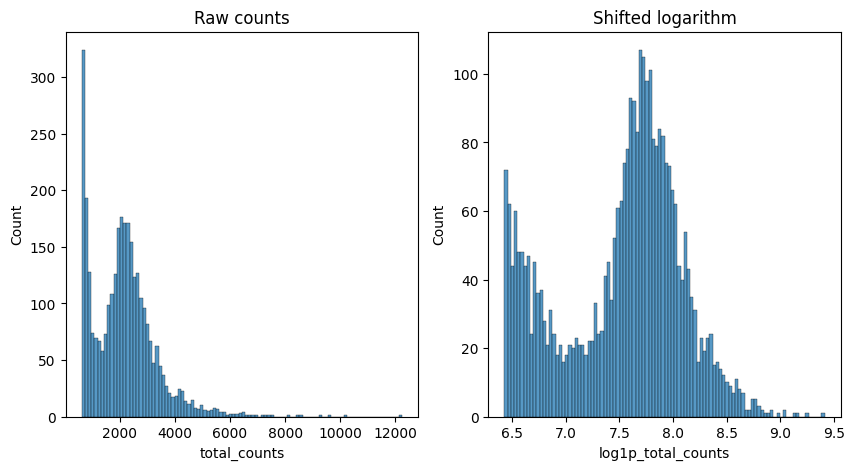

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Raw counts")
p2 = sns.histplot(adata.obs["log1p_total_counts"], bins=100, kde=False, ax=axes[1])
axes[1].set_title("Shifted logarithm")
plt.show()

In [6]:
print(adata.layers)

Layers with keys: raw_counts, soupx_counts, counts_for_normalisation, log1p_normalised


In [7]:
adata_hvg = adata.copy()
adata_hvg.X = adata_hvg.layers["log1p_normalised"].copy()

sc.pp.highly_variable_genes(
    adata_hvg,
    flavor="seurat_v3",
    n_top_genes=2000,
)

adata.var["highly_variable"] = adata_hvg.var["highly_variable"].values
print(f"HVGs: {adata.var['highly_variable'].sum()}")

del adata_hvg

HVGs: 2000


/Users/wangj/Documents/Computational Biology/Projects/sc-pbmc3k/sc_env/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)


In [8]:
# Use the "log1p_normalised" layer for PCA.
adata_hvg = adata.copy()

adata_hvg.X = adata_hvg.layers["log1p_normalised"].copy()
adata_hvg.raw = adata_hvg.copy()

adata_hvg = adata_hvg[:, adata_hvg.var["highly_variable"]].copy()

print(f"After HVG subsetting: {adata_hvg.shape}")
# Different from the earlier normalisation and log1p transformation, data needs to be scaled so that every gene has a mean of 0 and a variance / standard deviation of 1.
# Earlier normalisation: every cell's sequencing depth.
# Earlier log1p: compress the range of cell counts. 
sc.pp.scale(adata_hvg, max_value=10)
sc.tl.pca(adata_hvg, n_comps=50, svd_solver="arpack")
# The algorithm looks at the first 30 PCs to draw edges between each cell and its 15 nearest neighbours, creating a neighbourhood graph. 
sc.pp.neighbors(adata_hvg, n_neighbors=15, n_pcs=30)
# UMAP visualises the neighbourhood graph in 2D.
sc.tl.umap(adata_hvg)
# The Leiden algorithm turns the neighbourhoods into discrete clusters. 
sc.tl.leiden(adata_hvg, resolution=0.6)

After HVG subsetting: (3213, 2000)


/opt/anaconda3/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/Users/wangj/Documents/Computational Biology/Projects/sc-pbmc3k/sc_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/b0/nvzw55rs7y92rywcfyhwkq_xc2qgzh/T/ipykernel_13638/1624801279.py:20: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_hvg, resolution=0.6)


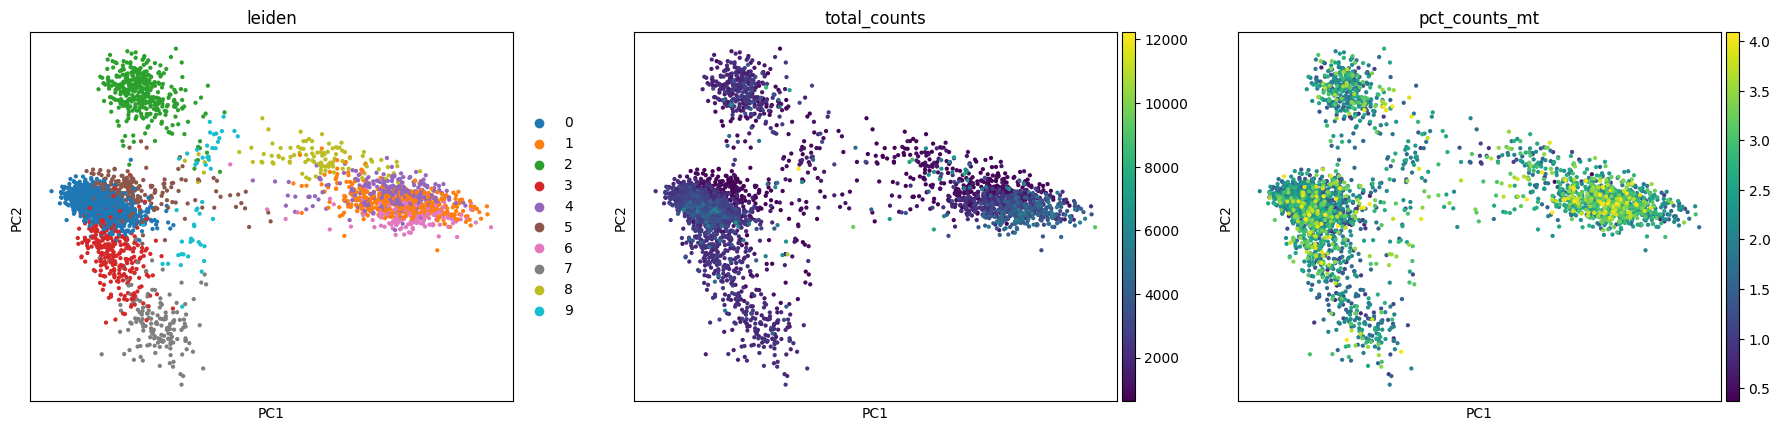

In [9]:
# Visualise PCA scatter (PC1 vs PC2)
sc.pl.pca(
    adata_hvg,
    color=["leiden", "total_counts", "pct_counts_mt"],
    components="1,2"
)

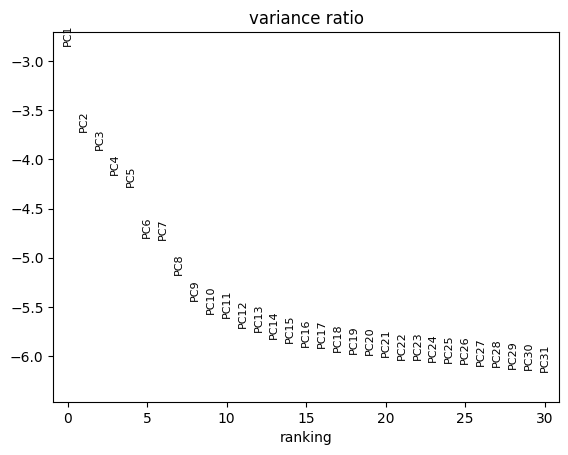

In [10]:
# Visualise the PCA elbow plot / scree plot.
sc.pl.pca_variance_ratio(adata_hvg, log=True)

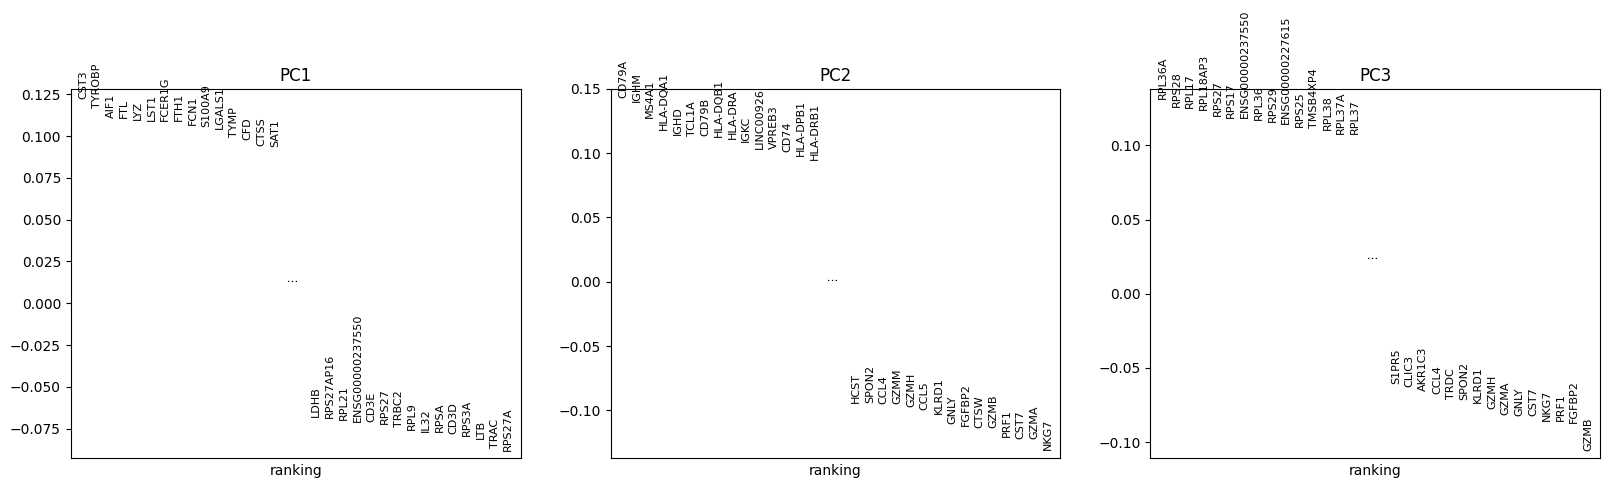

In [11]:
# PCA loadings - which genes drive PCs
sc.pl.pca_loadings(adata_hvg,components=[1,2,3], n_points=30)

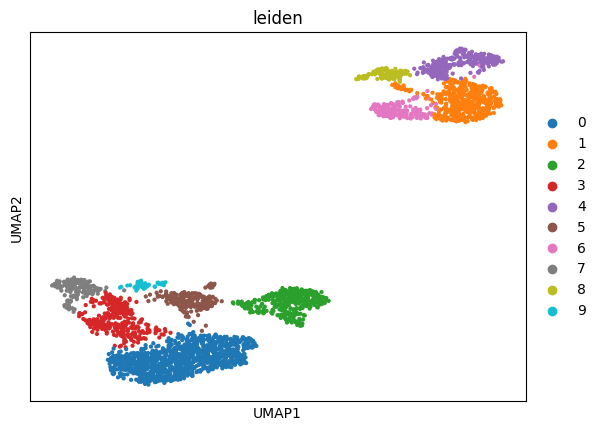

In [12]:
# Look at the main UMAP.
sc.pl.umap(adata_hvg, color=['leiden'])

In [13]:
print(adata_hvg.obs.columns.tolist())

['n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'soupx_clustering', 'doublet_score_scrublet', 'predicted_doublet_scrublet', 'leiden']


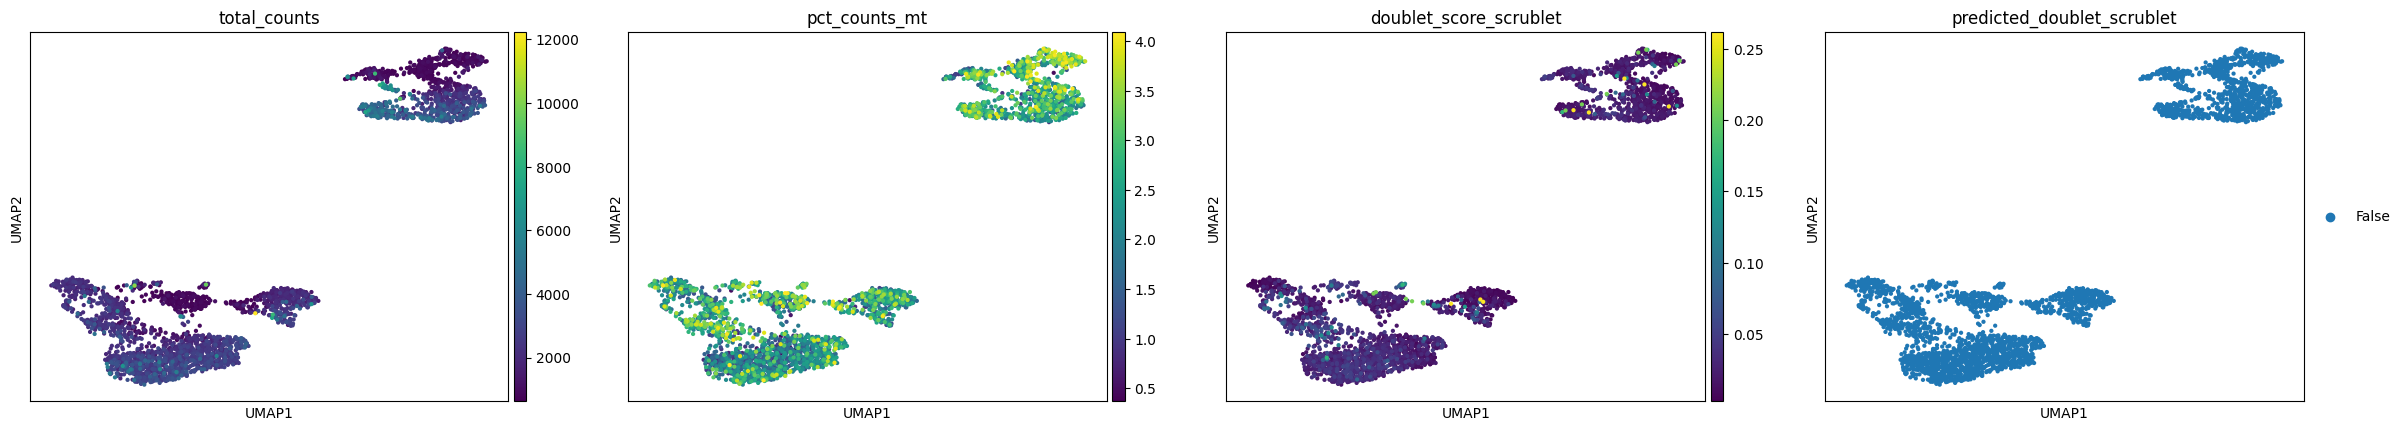

In [14]:
# Look at the technical UMAP.
sc.pl.umap(adata_hvg, color=["total_counts", "pct_counts_mt", "doublet_score_scrublet", "predicted_doublet_scrublet"])

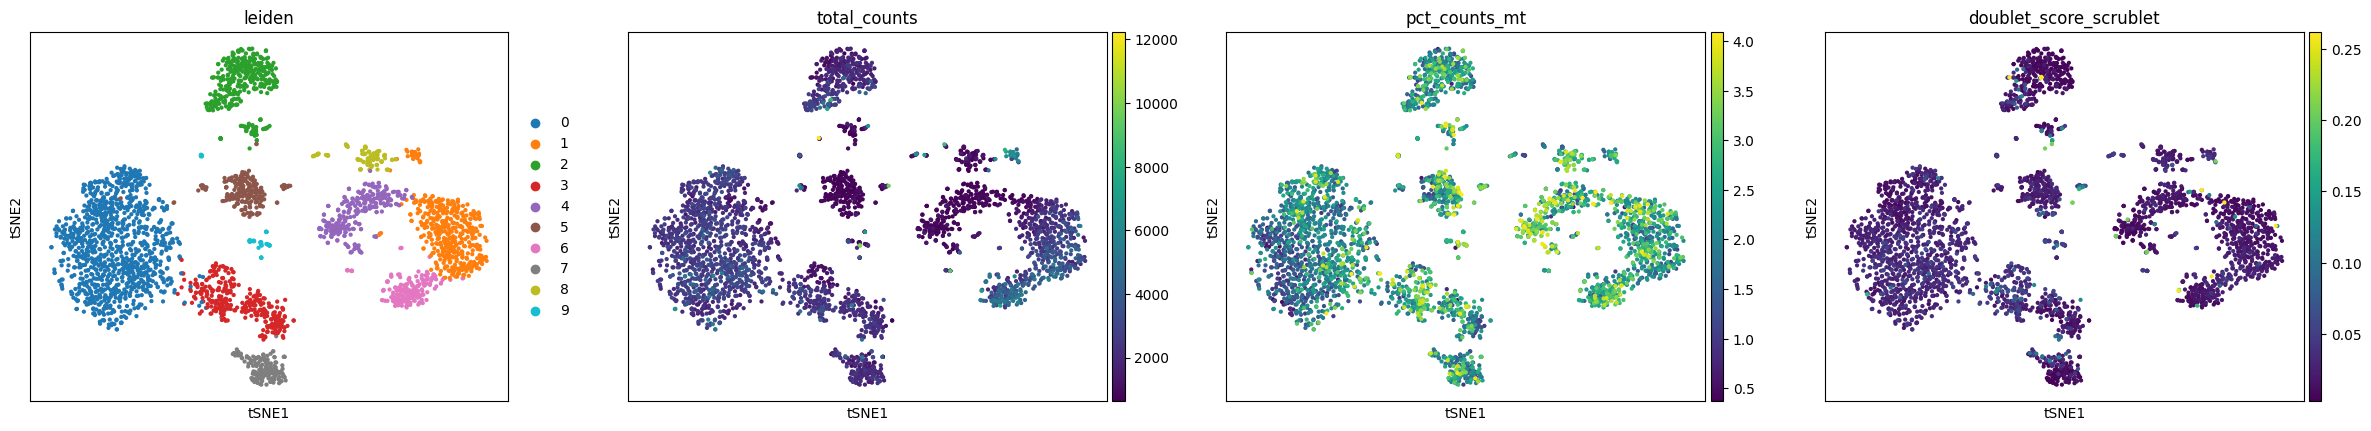

In [15]:
sc.tl.tsne(adata_hvg, n_pcs=30, perplexity=30, learning_rate="auto", random_state=0)
sc.pl.tsne(
    adata_hvg,
    color=["leiden", "total_counts", "pct_counts_mt", "doublet_score_scrublet"]
)

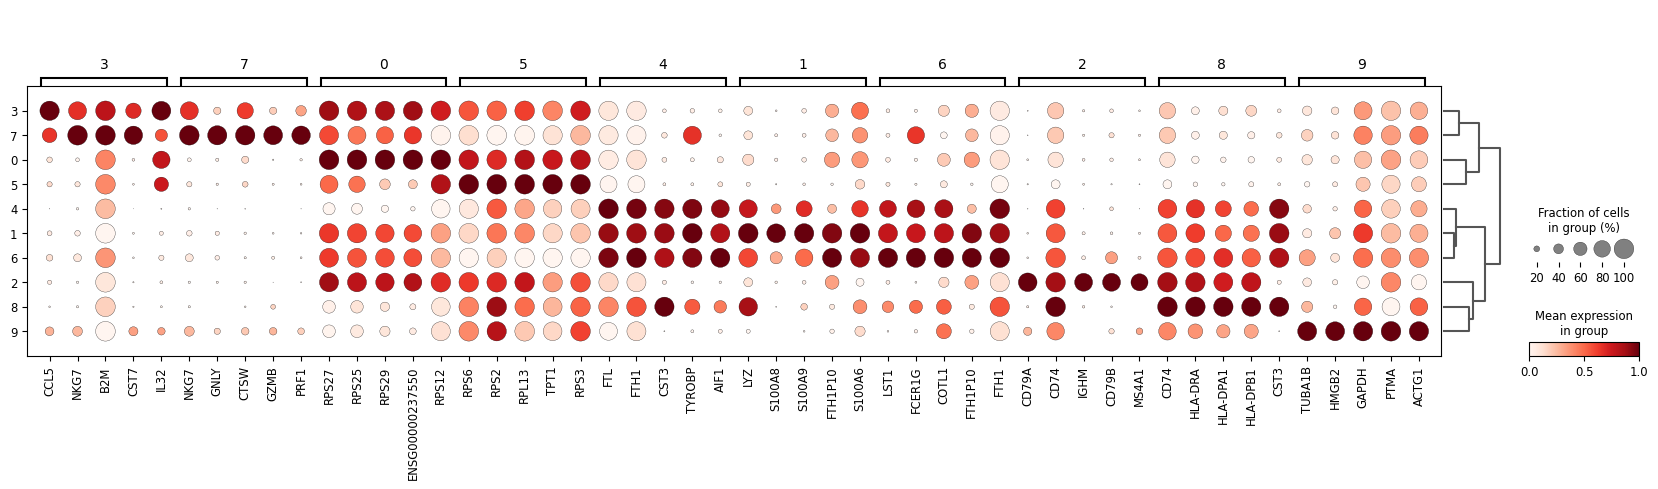

In [16]:
# Run Differential Expression analysis and Rank the marker genes per cluster.
sc.tl.rank_genes_groups(
    adata_hvg,
    groupby="leiden",
    method="wilcoxon",
    use_raw=True, # adata_hvg.raw contains the log1p_normalised data before HVG subsetting.
    key_added="dea_leiden"
)

# Visualise as dotplot
sc.pl.rank_genes_groups_dotplot(
    adata_hvg,
    groupby="leiden",
    n_genes=5,
    standard_scale="var",
    key="dea_leiden",
    use_raw=True
)

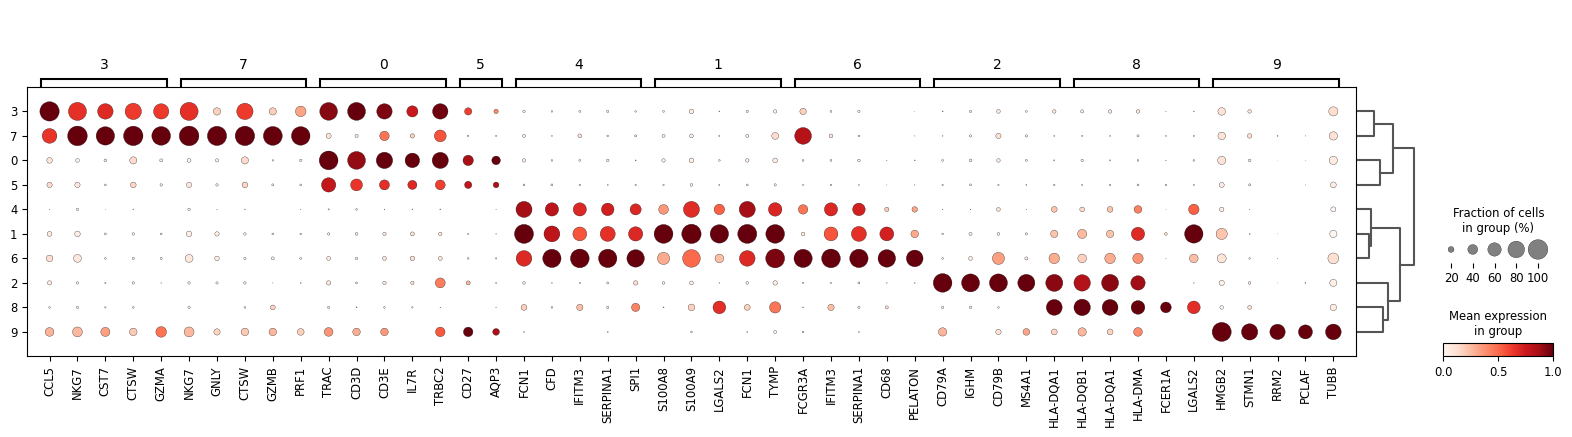

In [17]:
# Filter the ranked differentially expressed genes 
sc.tl.filter_rank_genes_groups(
    adata_hvg,
    min_in_group_fraction = 0.1,
    max_out_group_fraction = 0.3,
    key = "dea_leiden",
    key_added = "dea_leiden_filtered"
)

# Plot the filtered marker genes
sc.pl.rank_genes_groups_dotplot(
    adata_hvg,
    groupby="leiden",
    standard_scale = "var",
    n_genes=5,
    key="dea_leiden_filtered"
)

In [18]:
# Save checkpoint.
adata.write_h5ad(f"{processed_data_path}/04_normalise_hvg_annotation.h5ad")